In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from probeinterface import get_probe, write_probeinterface

from format_waveform_data import map_contacts_simple

In [2]:
''' File paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "LMN86"
session_id = "260831"
ephys_id = "LMN86_260831_110849"
map_file = 'H15_128Chan_IntanMap.xlsx'
cmr = False

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# probe map
map_file_path = f'Z:/Isabel/ephys/channel_maps/{map_file}'

# to save files
sort_dir = f"{intan_folder}/bombcell/"

In [3]:
''' load the recording and get params '''
recording = se.read_intan(f"{intan_folder}info.rhd", stream_id='0')
fs = recording.get_sampling_frequency()

In [4]:
''' get probe contact sort '''
contact_sort, ch_names, shank_idx = map_contacts_simple(map_file_path)

In [5]:
ch_names_sorted = []
for c in contact_sort:
    ch_names_sorted.append(ch_names[c])

In [6]:
bad_idx = np.asarray([3, 4, 5, 6, 7, 52, 54, 70, 72, 94, 96, 98, 100, 104, 106, 122, 124, 126, 128]).astype(int) - 1
bad_idx = np.append(bad_idx, np.arange(64, 128))
bad_idx = np.unique(bad_idx)
bad_ch = []
for b in bad_idx:
    bad_ch.append(ch_names_sorted[b])

bad_idx_sorted = []
for bad in bad_ch:
    bad_idx_sorted.append(ch_names.index(bad))
bad_idx_sorted = np.asarray(bad_idx_sorted).astype(int)

In [7]:
for bs, b in zip(bad_idx_sorted, bad_idx):
    print(ch_names[bs])
    print(ch_names_sorted[b])

A-03-1
A-03-1
A-04-2
A-04-2
A-05-1
A-05-1
A-06-2
A-06-2
A-07-1
A-07-1
A-17-1
A-17-1
A-39-1
A-39-1
A-47-1
A-47-1
A-55-1
A-55-1
A-63-1
A-63-1
A-50-2
A-50-2
B-01-1
B-01-1
B-02-2
B-02-2
B-03-1
B-03-1
B-04-2
B-04-2
B-05-1
B-05-1
B-06-2
B-06-2
B-07-1
B-07-1
B-08-2
B-08-2
B-09-1
B-09-1
B-10-2
B-10-2
B-11-1
B-11-1
B-12-2
B-12-2
B-13-1
B-13-1
B-14-2
B-14-2
B-15-1
B-15-1
B-16-2
B-16-2
B-64-2
B-64-2
B-17-1
B-17-1
B-19-1
B-19-1
B-20-2
B-20-2
B-21-1
B-21-1
B-22-2
B-22-2
B-23-1
B-23-1
B-24-2
B-24-2
B-25-1
B-25-1
B-26-2
B-26-2
B-27-1
B-27-1
B-28-2
B-28-2
B-29-1
B-29-1
B-30-2
B-30-2
B-32-2
B-32-2
B-34-2
B-34-2
B-18-2
B-18-2
B-33-1
B-33-1
B-37-1
B-37-1
B-41-1
B-41-1
B-45-1
B-45-1
B-49-1
B-49-1
B-53-1
B-53-1
B-57-1
B-57-1
B-61-1
B-61-1
B-36-2
B-36-2
B-40-2
B-40-2
B-44-2
B-44-2
B-48-2
B-48-2
B-52-2
B-52-2
B-56-2
B-56-2
B-60-2
B-60-2
B-35-1
B-35-1
B-39-1
B-39-1
B-43-1
B-43-1
B-47-1
B-47-1
B-51-1
B-51-1
B-55-1
B-55-1
B-59-1
B-59-1
B-63-1
B-63-1
B-38-2
B-38-2
B-42-2
B-42-2
B-46-2
B-46-2
B-50-2
B-50-2
B-54-2

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

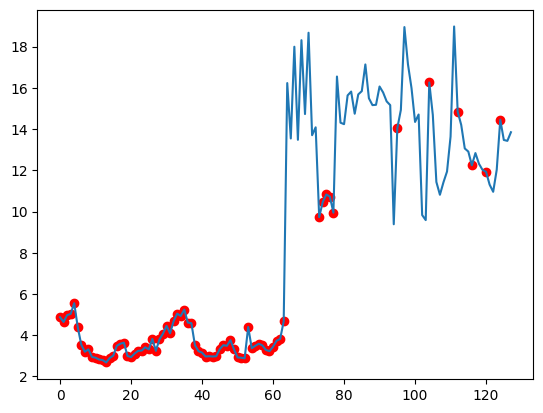

In [8]:
''' find and exclude noisy channels '''
noise_level = si.get_noise_levels(spre.common_reference(spre.highpass_filter(recording)))
plt.plot(noise_level)
plt.scatter(bad_idx_sorted, noise_level[bad_idx_sorted], c='r')
# plt.hlines(10, 0, 128)

In [9]:
# set noise threshold and remove noisy channels
n_channels = len(ch_names)
all_ch_idx = np.arange(n_channels)
noise_thresh = 11
keep_ch_idx = noise_level < noise_thresh
bad_channel_idx = all_ch_idx[~keep_ch_idx]

print(f"excluding {np.sum(~keep_ch_idx)} channel(s)")

excluding 54 channel(s)


In [10]:
bad_channel_idx = bad_idx_sorted

In [11]:
np.sort(bad_channel_idx)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  73,
        74,  75,  76,  77,  95, 104, 112, 116, 120, 124])

In [12]:
# check the gain
gains = recording.get_channel_gains()
assert np.allclose(gains, gains[0]), "expected uniform gain across channels"
gain_to_uV = float(gains[0])   # typically 0.195 for Intan RHD-based systems
print()

In [13]:
# common median reference if needed
if cmr:
    rec_cmr = spre.common_reference(recording, reference="global", operator="median")
else:
    rec_cmr = recording

In [14]:
# to save files
sort_dir = f"{intan_folder}/bombcell/"

In [15]:
bad_channel_string = ''
for b_idx in bad_channel_idx:
    bad_channel_string = bad_channel_string + f'{b_idx}, '

print(f"Binary save path: {sort_dir}/traces_cached_seg0.raw")
print(f"Channel index to exlude: [{bad_channel_string}], fs: {fs}, gain_to_uV: {gain_to_uV}")

Binary save path: C:/Users/Isabel/Documents/data_temp/LMN86_260828/LMN86_260828_121914//bombcell//traces_cached_seg0.raw
Channel index to exlude: [77, 76, 75, 74, 73, 95, 124, 120, 116, 112, 104, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0, 33, 31, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 30, 63, 61, 59, 57, 55, 53, 51, 49, 47, 45, 43, 41, 39, 37, 35, 62, 60, 58, 56, 54, 52, 50, 48, 46, 44, 42, 40, 38, 36, 34, 32, ], fs: 30000.0, gain_to_uV: 0.195


In [ ]:
# save as binary for KS4 and BC
rec_cmr.save(format="binary", folder=sort_dir, dtype="int16", 
             n_jobs=8, chunk_duration="1s")